# QM640 Food Price Affordability AI
## Notebook 06 — Multi-Horizon Price-Shock Classification

This notebook extends RQ2 from continuous price forecasts to rare-event
classification. A shock is a future positive price change at or above the
commodity-specific 90th percentile estimated only from data available before
each forecast origin. This prevents look-ahead leakage and avoids imposing one
threshold on commodities with very different volatility.


## 1. Setup and verified inputs


In [1]:
from pathlib import Path
import json, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 190)

try:
    import google.colab  # noqa
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = Path("/content/drive/MyDrive/QM640_Food_Affordability")
else:
    root = Path.cwd().resolve()
    if root.name == "notebooks": root = root.parent
    OUTPUT_ROOT = Path(os.environ.get("QM640_OUTPUT_ROOT", str(root)))

PROCESSED = OUTPUT_ROOT / "data" / "processed"
REPORT_OUTPUT = OUTPUT_ROOT / "reports" / "notebook_outputs"
FIGURES = REPORT_OUTPUT / "figures"
REPORT_OUTPUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
SKIP_PLOTS = os.environ.get("QM640_SKIP_PLOTS", "0") == "1"

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
if not SKIP_PLOTS:
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.set_theme(style="whitegrid")

state = pd.read_csv(PROCESSED / "cleaned_state_monthly.csv.gz", parse_dates=["date"], low_memory=False)
nb05 = json.loads((REPORT_OUTPUT / "05_execution_summary.json").read_text(encoding="utf-8"))
forecast_predictions = pd.read_csv(
    REPORT_OUTPUT / "05_panel_rolling_predictions.csv.gz", parse_dates=["origin"]
)
print(f"State rows: {len(state):,}; Notebook 05 panel predictions: {len(forecast_predictions):,}")


Mounted at /content/drive
State rows: 41,792; Notebook 05 panel predictions: 12,540


## 2. Leakage-safe shock definitions and features


In [2]:
TARGETS = {1: "future_price_change_h1m_pct", 2: "future_price_change_h2m_pct", 3: "future_price_change_h3m_pct"}
numeric_features = [
    "price_mom_pct", "price_yoy_pct", "rainfall_anomaly_pct",
    "temperature_anomaly_c", "relative_humidity_pct",
    "production_tonne", "yield_kg_per_hectare",
    "rural_wage_rs_per_day", "source_rows",
]
numeric_features = [c for c in numeric_features if c in state.columns]
categorical_features = ["region", "Commodity", "month"]
feature_columns = numeric_features + categorical_features
data = state.copy()
data["month"] = data["date"].dt.month.astype(str)
origin_dates = sorted(forecast_predictions["origin"].drop_duplicates())

logit_prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])
tree_prep = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
])

def classifiers():
    return {
        "logistic_balanced": Pipeline([
            ("prep", logit_prep),
            ("model", LogisticRegression(
                class_weight="balanced", max_iter=1000, C=0.5, random_state=640
            )),
        ]),
        "hist_gradient_boosting": Pipeline([
            ("prep", tree_prep),
            ("model", HistGradientBoostingClassifier(
                learning_rate=0.05, max_iter=160, max_leaf_nodes=20,
                min_samples_leaf=30, l2_regularization=1.0, random_state=640
            )),
        ]),
    }


## 3. Expanding-origin shock classification


In [3]:
prediction_rows, threshold_rows = [], []
for horizon, target in TARGETS.items():
    for origin in origin_dates:
        train = data.loc[data["date"].lt(origin) & data[target].notna()].copy()
        test = data.loc[data["date"].eq(origin) & data[target].notna()].copy()
        if len(train) < 1000 or len(test) == 0:
            continue
        thresholds = (
            train.groupby("Commodity", observed=True)[target]
            .quantile(0.90).rename("shock_threshold_pct")
        )
        train = train.join(thresholds, on="Commodity")
        test = test.join(thresholds, on="Commodity")
        train["shock"] = train[target].ge(train["shock_threshold_pct"]).astype(int)
        test["shock"] = test[target].ge(test["shock_threshold_pct"]).astype(int)
        for commodity, value in thresholds.items():
            threshold_rows.append({
                "horizon_months": horizon, "origin": origin,
                "Commodity": str(commodity), "shock_threshold_pct": float(value),
            })

        # Persistence benchmark: current positive YoY pressure above its training 90th percentile.
        current_threshold = float(train["price_yoy_pct"].quantile(0.90))
        persistence_probability = train["shock"].mean() + (
            test["price_yoy_pct"].ge(current_threshold).astype(float) * 0.75
        )
        persistence_probability = persistence_probability.clip(0, 1)
        for idx, probability in enumerate(persistence_probability):
            prediction_rows.append({
                "horizon_months": horizon, "origin": origin,
                "region": str(test.iloc[idx]["region"]),
                "Commodity": str(test.iloc[idx]["Commodity"]),
                "model": "persistence", "actual_shock": int(test.iloc[idx]["shock"]),
                "probability": float(probability),
            })

        for model_name, model in classifiers().items():
            if model_name == "hist_gradient_boosting":
                prevalence = train["shock"].mean()
                weights = np.where(train["shock"].eq(1), 0.5 / prevalence, 0.5 / (1 - prevalence))
                model.fit(train[feature_columns], train["shock"], model__sample_weight=weights)
            else:
                model.fit(train[feature_columns], train["shock"])
            probabilities = model.predict_proba(test[feature_columns])[:, 1]
            for idx, probability in enumerate(probabilities):
                prediction_rows.append({
                    "horizon_months": horizon, "origin": origin,
                    "region": str(test.iloc[idx]["region"]),
                    "Commodity": str(test.iloc[idx]["Commodity"]),
                    "model": model_name, "actual_shock": int(test.iloc[idx]["shock"]),
                    "probability": float(probability),
                })
    print(f"Completed shock horizon {horizon}/3")

shock_predictions = pd.DataFrame(prediction_rows)
shock_predictions["predicted_shock"] = shock_predictions["probability"].ge(0.50).astype(int)
threshold_history = pd.DataFrame(threshold_rows)
shock_predictions.to_csv(REPORT_OUTPUT / "06_rolling_shock_predictions.csv.gz", index=False, compression="gzip")
threshold_history.to_csv(REPORT_OUTPUT / "06_training_only_shock_thresholds.csv", index=False)


Completed shock horizon 1/3
Completed shock horizon 2/3
Completed shock horizon 3/3


## 4. Rare-event performance and model selection


In [4]:
metric_rows = []
for (horizon, model_name), group in shock_predictions.groupby(["horizon_months", "model"]):
    y = group["actual_shock"].to_numpy()
    p = group["probability"].to_numpy()
    pred = group["predicted_shock"].to_numpy()
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    metric_rows.append({
        "horizon_months": int(horizon), "model": model_name, "n": int(len(group)),
        "shock_prevalence": float(y.mean()),
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred, zero_division=0),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "f1": f1_score(y, pred, zero_division=0),
        "roc_auc": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "average_precision": average_precision_score(y, p),
        "brier_score": brier_score_loss(y, p),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    })
metrics = pd.DataFrame(metric_rows).sort_values(
    ["horizon_months", "average_precision"], ascending=[True, False]
)
selected = (
    metrics.sort_values(["horizon_months", "average_precision", "balanced_accuracy"], ascending=[True, False, False])
    .groupby("horizon_months", as_index=False).first()
)
metrics.to_csv(REPORT_OUTPUT / "06_shock_classifier_metrics.csv", index=False)
selected.to_csv(REPORT_OUTPUT / "06_selected_shock_models.csv", index=False)
print(metrics.round(4).to_string(index=False))
print("\nSelected by average precision")
print(selected[["horizon_months", "model", "average_precision", "balanced_accuracy", "recall"]].round(4).to_string(index=False))


 horizon_months                  model    n  shock_prevalence  accuracy  balanced_accuracy  precision  recall  specificity     f1  roc_auc  average_precision  brier_score  tp  tn  fp  fn
              1 hist_gradient_boosting 1054            0.0693    0.7856             0.7136     0.1878  0.6301       0.7971 0.2893   0.8204             0.3307       0.1502  46 782 199  27
              1      logistic_balanced 1054            0.0693    0.7201             0.6785     0.1465  0.6301       0.7268 0.2377   0.7352             0.2323       0.1955  46 713 268  27
              1            persistence 1054            0.0693    0.8852             0.5263     0.1250  0.1096       0.9429 0.1168   0.3771             0.0680       0.0973   8 925  56  65
              2 hist_gradient_boosting 1040            0.0635    0.7490             0.7601     0.1717  0.7727       0.7474 0.2810   0.8391             0.3113       0.1690  51 728 246  15
              2      logistic_balanced 1040            0.0635    

## 5. Forward 1–3 month conditional risk watch


feature_date target_date  horizon_months            region Commodity         selected_model  shock_threshold_pct  shock_probability                            input_status
  2026-07-01  2026-10-01               3             Delhi      Rice hist_gradient_boosting              12.4571             0.8205 latest observed predictors; conditional
  2026-07-01  2026-08-01               1             Delhi      Rice hist_gradient_boosting               6.8024             0.8185 latest observed predictors; conditional
  2026-07-01  2026-08-01               1            Punjab     Onion hist_gradient_boosting              31.4445             0.7911 latest observed predictors; conditional
  2026-07-01  2026-08-01               1           Haryana     Onion hist_gradient_boosting              31.4445             0.7870 latest observed predictors; conditional
  2026-07-01  2026-08-01               1     Uttar Pradesh     Onion hist_gradient_boosting              31.4445             0.7848 latest o

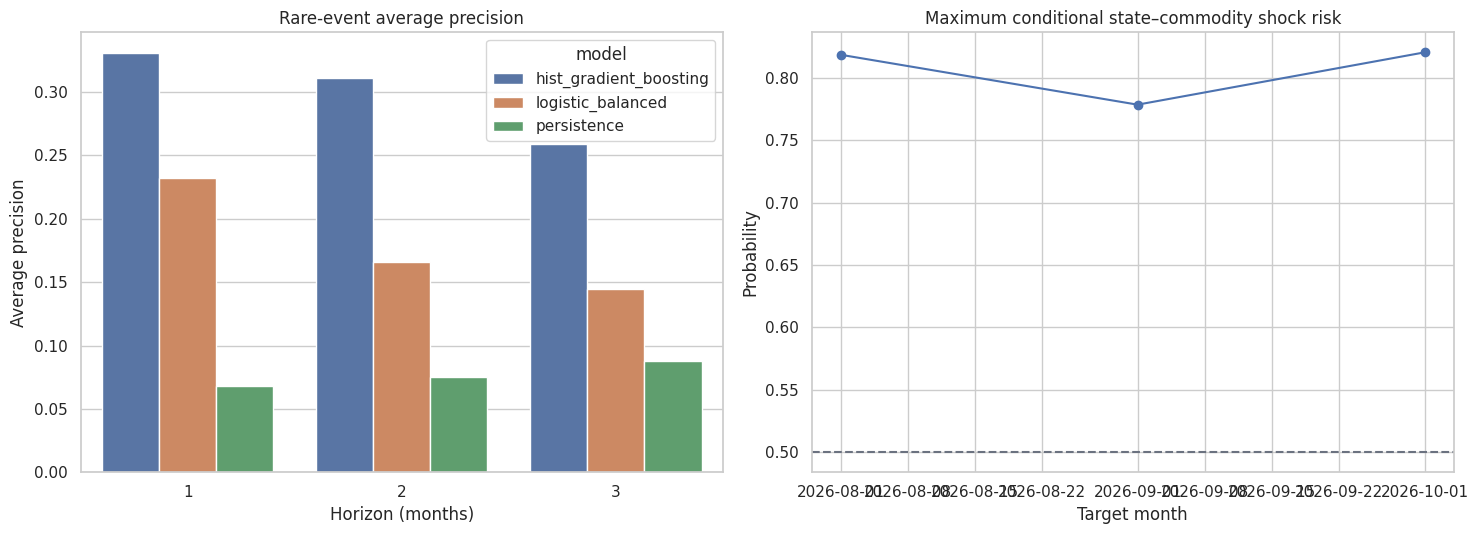

In [5]:
latest_date = data["date"].max()
latest = data.loc[data["date"].eq(latest_date)].copy()
forward_rows = []
for horizon, target in TARGETS.items():
    train = data.loc[data[target].notna()].copy()
    thresholds = train.groupby("Commodity", observed=True)[target].quantile(0.90)
    train = train.join(thresholds.rename("shock_threshold_pct"), on="Commodity")
    train["shock"] = train[target].ge(train["shock_threshold_pct"]).astype(int)
    model_name = str(selected.loc[selected["horizon_months"].eq(horizon), "model"].iloc[0])
    if model_name == "persistence":
        current_threshold = float(train["price_yoy_pct"].quantile(0.90))
        probabilities = (
            train["shock"].mean() + latest["price_yoy_pct"].ge(current_threshold).astype(float) * 0.75
        ).clip(0, 1).to_numpy()
    else:
        model = classifiers()[model_name]
        if model_name == "hist_gradient_boosting":
            prevalence = train["shock"].mean()
            weights = np.where(train["shock"].eq(1), 0.5 / prevalence, 0.5 / (1 - prevalence))
            model.fit(train[feature_columns], train["shock"], model__sample_weight=weights)
        else:
            model.fit(train[feature_columns], train["shock"])
        probabilities = model.predict_proba(latest[feature_columns])[:, 1]
    target_date = latest_date + pd.DateOffset(months=horizon)
    for idx, probability in enumerate(probabilities):
        commodity = latest.iloc[idx]["Commodity"]
        forward_rows.append({
            "feature_date": latest_date, "target_date": target_date,
            "horizon_months": horizon, "region": str(latest.iloc[idx]["region"]),
            "Commodity": str(commodity), "selected_model": model_name,
            "shock_threshold_pct": float(thresholds.loc[commodity]),
            "shock_probability": float(probability),
            "input_status": "latest observed predictors; conditional",
        })
forward_risk = pd.DataFrame(forward_rows)
forward_risk.to_csv(REPORT_OUTPUT / "06_forward_multihorizon_shock_risk.csv", index=False)
top_risk = forward_risk.sort_values("shock_probability", ascending=False).head(20)
print(top_risk.round(4).to_string(index=False))

if not SKIP_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.barplot(data=metrics, x="horizon_months", y="average_precision", hue="model", ax=axes[0])
    axes[0].set(title="Rare-event average precision", xlabel="Horizon (months)", ylabel="Average precision")
    plot = forward_risk.groupby(["target_date", "horizon_months"], as_index=False)["shock_probability"].max()
    axes[1].plot(plot["target_date"], plot["shock_probability"], marker="o")
    axes[1].axhline(0.5, linestyle="--", color="#6b7280")
    axes[1].set(title="Maximum conditional state–commodity shock risk", xlabel="Target month", ylabel="Probability")
    fig.tight_layout()
    fig.savefig(FIGURES / "06_aligned_shock_results.png", bbox_inches="tight")
    plt.show()


## 6. Execution summary


In [6]:
summary = {
    "notebook": "06_shock_classification_synopsis_aligned",
    "status": "completed",
    "shock_definition": "Commodity-specific future price change at or above training-only 90th percentile",
    "horizons_months": [1, 2, 3],
    "rolling_origins": len(origin_dates),
    "evaluation_start": str(min(origin_dates).date()),
    "evaluation_end": str(max(origin_dates).date()),
    "selected_models": {
        f"{int(row.horizon_months)}_month": row.model for row in selected.itertuples()
    },
    "selected_metrics": {
        f"{int(row.horizon_months)}_month": {
            "balanced_accuracy": float(row.balanced_accuracy),
            "recall": float(row.recall),
            "average_precision": float(row.average_precision),
            "brier_score": float(row.brier_score),
            "observed_shocks": int(row.tp + row.fn),
        } for row in selected.itertuples()
    },
    "forward_feature_date": str(latest_date.date()),
    "forward_target_dates": sorted(forward_risk["target_date"].dt.strftime("%Y-%m-%d").unique().tolist()),
    "highest_forward_risk": float(forward_risk["shock_probability"].max()),
    "highest_forward_risk_region": str(forward_risk.loc[forward_risk["shock_probability"].idxmax(), "region"]),
    "highest_forward_risk_commodity": str(forward_risk.loc[forward_risk["shock_probability"].idxmax(), "Commodity"]),
    "interpretation": "Predictive conditional risk; not a causal or automatic policy trigger.",
    "output_root": str(OUTPUT_ROOT),
}
SUMMARY_FILE = REPORT_OUTPUT / "06_execution_summary.json"
SUMMARY_FILE.write_text(json.dumps(summary, indent=2), encoding="utf-8")
expected = [
    REPORT_OUTPUT / "06_rolling_shock_predictions.csv.gz",
    REPORT_OUTPUT / "06_training_only_shock_thresholds.csv",
    REPORT_OUTPUT / "06_shock_classifier_metrics.csv",
    REPORT_OUTPUT / "06_selected_shock_models.csv",
    REPORT_OUTPUT / "06_forward_multihorizon_shock_risk.csv",
    SUMMARY_FILE,
]
if not SKIP_PLOTS: expected.append(FIGURES / "06_aligned_shock_results.png")
missing = [str(p) for p in expected if not p.exists()]
if missing: raise FileNotFoundError("\n".join(missing))
print("=" * 76)
print("NOTEBOOK 06 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT")
print("=" * 76)
print(json.dumps(summary, indent=2))
print(f"\nVerified artifacts: {len(expected)}")


NOTEBOOK 06 ALIGNED EXECUTION SUMMARY — PLEASE SHARE THIS OUTPUT
{
  "notebook": "06_shock_classification_synopsis_aligned",
  "status": "completed",
  "shock_definition": "Commodity-specific future price change at or above training-only 90th percentile",
  "horizons_months": [
    1,
    2,
    3
  ],
  "rolling_origins": 8,
  "evaluation_start": "2024-05-01",
  "evaluation_end": "2026-02-01",
  "selected_models": {
    "1_month": "hist_gradient_boosting",
    "2_month": "hist_gradient_boosting",
    "3_month": "hist_gradient_boosting"
  },
  "selected_metrics": {
    "1_month": {
      "balanced_accuracy": 0.7136413779621018,
      "recall": 0.6301369863013698,
      "average_precision": 0.33066689258269805,
      "brier_score": 0.15017245243902724,
      "observed_shocks": 73
    },
    "2_month": {
      "balanced_accuracy": 0.7600802688071682,
      "recall": 0.7727272727272727,
      "average_precision": 0.311314544490061,
      "brier_score": 0.1690385982037376,
      "observed_

## Notebook 06 conclusion

The classification results complement—not replace—the continuous forecast
tests. Precision-recall measures are emphasized because shocks are rare.
Probabilities are conditional monitoring signals and must not be converted
directly into automated procurement or policy decisions.
